# Molecular Graph Learning Curve

This notebook measures how predictive performance on the MoleculeNet HIV dataset changes as the number of streamed training graphs increases, using `NSPPK` features with `radius=1`, `distance=4`, `connector=1` and a linear `SGDClassifier`.

The first `TEST_PREFIX_SIZE` molecules are materialized, balanced, and used as a fixed test set. Training is then repeated on random Bernoulli samples from the remaining molecules with `LIMIT = 0.9`, so each repeat sees a different large training stream while the same held-out test set is scored at exponentially growing train sizes.


In [1]:
from pathlib import Path
import gc
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import RDLogger
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

try:
    import psutil
except ImportError:
    psutil = None

REPO_CANDIDATES = [Path.cwd().resolve(), Path.cwd().resolve().parent]
REPO_ROOT = next(candidate for candidate in REPO_CANDIDATES if (candidate / 'src').exists())
SRC_DIR = REPO_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import graph_io as _graph_io
from nsppk import NSPPK
from utils import plot_series_with_band_loess

DATASET_FILE = REPO_ROOT / 'data' / 'HIV.csv'
NBIT = 14
RADIUS = 1
DISTANCE = 4
CONNECTOR = 1
LIMIT = 0.9
TEST_PREFIX_SIZE = 2000
BALANCE_TEST_SET = True
TRAIN_SIZE_VALUES = None
N_REPEATS = 3
BATCH_SIZE = 256
WARMUP_SIZE = 256
PARALLEL = True
RANDOM_STATE = 42

RDLogger.DisableLog('rdApp.*')

def current_rss_mb():
    if psutil is not None:
        return psutil.Process(os.getpid()).memory_info().rss / (1024 ** 2)
    import resource
    rss = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    if sys.platform == 'darwin':
        return rss / (1024 ** 2)
    return rss / 1024

MEMORY_LOG = []
MEMORY_PEAK_MB = 0.0

def record_memory(stage, emit=True):
    global MEMORY_PEAK_MB
    rss_mb = float(current_rss_mb())
    MEMORY_PEAK_MB = max(MEMORY_PEAK_MB, rss_mb)
    event = {'stage': stage, 'rss_mb': rss_mb, 'peak_rss_mb': MEMORY_PEAK_MB}
    MEMORY_LOG.append(event)
    if emit:
        print(f"[memory] {stage:<28} rss={rss_mb:8.2f} MB  peak={MEMORY_PEAK_MB:8.2f} MB")
    return event

def count_dataset_rows(dataset_file):
    with Path(dataset_file).open() as stream:
        return max(sum(1 for _ in stream) - 1, 0)

def resolve_limit_count(limit, available_count):
    if limit is None:
        return int(available_count)
    if isinstance(limit, int):
        return min(int(limit), int(available_count))
    return min(int(np.floor(float(limit) * available_count)), int(available_count))

def make_exponential_train_sizes(train_limit, min_size=250):
    if train_limit <= 0:
        return []
    if TRAIN_SIZE_VALUES is not None:
        return [n for n in TRAIN_SIZE_VALUES if n <= train_limit]
    train_sizes = []
    current = min_size
    while current <= train_limit:
        train_sizes.append(current)
        current *= 2
    return train_sizes


## Setup

Build the fixed balanced test set from the first `TEST_PREFIX_SIZE` molecules, warm up the vectorizer on the first training slice after that prefix, and convert the fractional `LIMIT` into an approximate sampled training-pool size. That estimated cap is then used to generate the exponential checkpoint schedule.


In [2]:
loader = NSPPK(radius=RADIUS, distance=DISTANCE, connector=CONNECTOR, nbits=NBIT, parallel=PARALLEL)
record_memory('start')

test_graphs = loader.load_from(
    DATASET_FILE,
    'smiles',
    limit=TEST_PREFIX_SIZE,
    balance=BALANCE_TEST_SET,
    random_state=RANDOM_STATE,
    label_extractor=lambda graph: int(graph.graph['HIV_active']),
)
y_test = np.asarray([int(graph.graph['HIV_active']) for graph in test_graphs])
record_memory('test set loaded')

dataset_size = count_dataset_rows(DATASET_FILE)
available_train_pool = max(dataset_size - TEST_PREFIX_SIZE, 0)
train_limit = resolve_limit_count(LIMIT, available_train_pool)
warmup_size = min(WARMUP_SIZE, train_limit)
warmup_graphs = loader.load_from(
    DATASET_FILE,
    'smiles',
    start_after_instance=TEST_PREFIX_SIZE,
    limit=warmup_size,
)
y_warmup = np.asarray([int(graph.graph['HIV_active']) for graph in warmup_graphs])
record_memory('warmup loaded')

vectorizer = NSPPK(
    radius=RADIUS,
    distance=DISTANCE,
    connector=CONNECTOR,
    nbits=NBIT,
    dense=False,
    parallel=PARALLEL,
)
vectorizer.fit(warmup_graphs)
record_memory('vectorizer fitted')
X_test = vectorizer.transform(test_graphs)
record_memory('test transformed')

classes = np.array([0, 1])
class_weight = None
if len(np.unique(y_warmup)) == len(classes):
    class_weight_values = compute_class_weight('balanced', classes=classes, y=y_warmup)
    class_weight = {cls: float(weight) for cls, weight in zip(classes, class_weight_values)}

train_size_values = make_exponential_train_sizes(train_limit)

print('test graphs:', len(test_graphs))
print(f'test positive rate: {y_test.mean():.3f}')
print('dataset size:', dataset_size)
print('available train pool:', available_train_pool)
print('train pool limit:', train_limit)
print('warmup graphs:', len(warmup_graphs))
print('class weight for partial_fit:', class_weight)
print('stream batch size:', BATCH_SIZE)
print('train sizes:', train_size_values)
print(f'initial peak RSS: {MEMORY_PEAK_MB:.2f} MB')


[memory] start                        rss=  265.96 MB  peak=  265.96 MB
[memory] test set loaded              rss= 1174.96 MB  peak= 1174.96 MB
[memory] warmup loaded                rss= 1174.97 MB  peak= 1174.97 MB
[memory] vectorizer fitted            rss= 1174.97 MB  peak= 1174.97 MB
[memory] test transformed             rss= 1248.07 MB  peak= 1248.07 MB
test graphs: 2000
test positive rate: 0.500
dataset size: 82255
available train pool: 80255
train pool limit: 72229
warmup graphs: 256
class weight for partial_fit: {np.int64(0): 0.5289256198347108, np.int64(1): 9.142857142857142}
stream batch size: 256
train sizes: [250, 500, 1000, 2000, 4000, 8000, 16000, 32000, 64000]
initial peak RSS: 1248.07 MB


## Incremental Learning Curve

Train `SGDClassifier` with `partial_fit(...)` on successive batches drawn from a repeat-specific Bernoulli half-sample of the post-test dataset. Metrics and memory are recorded whenever the cumulative trained count crosses one of the power-of-two checkpoints generated from the sampled training limit.


In [3]:
results = []

print(f"{'train':>8} | {'repeat':>6} | {'roc_auc':>8} | {'avg_prec':>8} | {'seconds':>8} | {'rss_mb':>8} | {'peak_mb':>8}")
print('-' * 79)

repeat_histories = {
    train_size: {'roc_auc': [], 'avg_precision': [], 'runtime_sec': [], 'rss_mb': [], 'peak_rss_mb': []}
    for train_size in train_size_values
}

for repeat_idx in range(1, N_REPEATS + 1):
    classifier = SGDClassifier(
        loss='log_loss',
        alpha=1e-5,
        penalty='l2',
        random_state=RANDOM_STATE + repeat_idx,
        class_weight=class_weight,
    )

    graph_iter = _graph_io._iter_loaded_graphs(
        DATASET_FILE,
        'smiles',
        limit=LIMIT,
        random_state=RANDOM_STATE + repeat_idx,
        start_after_instance=TEST_PREFIX_SIZE,
    )

    t0 = time.perf_counter()
    trained_count = 0
    checkpoint_idx = 0
    batch_graphs = []
    is_first_batch = True

    def flush_batch(batch_graphs, trained_count, checkpoint_idx, is_first_batch):
        y_batch = np.asarray([int(graph.graph['HIV_active']) for graph in batch_graphs])
        X_batch = vectorizer.transform(batch_graphs)

        if is_first_batch:
            classifier.partial_fit(X_batch, y_batch, classes=classes)
        else:
            classifier.partial_fit(X_batch, y_batch)

        trained_count += len(batch_graphs)
        del y_batch, X_batch
        gc.collect()

        while checkpoint_idx < len(train_size_values) and trained_count >= train_size_values[checkpoint_idx]:
            stop = train_size_values[checkpoint_idx]
            memory_event = record_memory(f'repeat {repeat_idx} train {stop}', emit=False)
            y_score = classifier.decision_function(X_test)
            runtime_sec = time.perf_counter() - t0
            roc_auc = roc_auc_score(y_test, y_score)
            avg_precision = average_precision_score(y_test, y_score)

            repeat_histories[stop]['roc_auc'].append(float(roc_auc))
            repeat_histories[stop]['avg_precision'].append(float(avg_precision))
            repeat_histories[stop]['runtime_sec'].append(float(runtime_sec))
            repeat_histories[stop]['rss_mb'].append(float(memory_event['rss_mb']))
            repeat_histories[stop]['peak_rss_mb'].append(float(memory_event['peak_rss_mb']))

            print(
                f"{stop:>8d} | {repeat_idx:>6d} | {roc_auc:>8.4f} | {avg_precision:>8.4f} | "
                f"{runtime_sec:>8.2f} | {memory_event['rss_mb']:>8.2f} | {memory_event['peak_rss_mb']:>8.2f}"
            )
            checkpoint_idx += 1

        return trained_count, checkpoint_idx, False

    for graph in graph_iter:
        batch_graphs.append(graph)
        next_checkpoint = train_size_values[checkpoint_idx] if checkpoint_idx < len(train_size_values) else None
        if len(batch_graphs) < BATCH_SIZE and (next_checkpoint is None or trained_count + len(batch_graphs) < next_checkpoint):
            continue
        trained_count, checkpoint_idx, is_first_batch = flush_batch(batch_graphs, trained_count, checkpoint_idx, is_first_batch)
        batch_graphs = []

    if batch_graphs:
        trained_count, checkpoint_idx, is_first_batch = flush_batch(batch_graphs, trained_count, checkpoint_idx, is_first_batch)

    print(f'repeat {repeat_idx} sampled train graphs: {trained_count}')

reached_train_sizes = []
skipped_train_sizes = []
for train_size in train_size_values:
    history = repeat_histories[train_size]
    if not history['roc_auc']:
        skipped_train_sizes.append(train_size)
        continue
    reached_train_sizes.append(train_size)
    results.append(
        {
            'train_size': train_size,
            'n_repeats_reached': len(history['roc_auc']),
            'mean_roc_auc': float(np.mean(history['roc_auc'])),
            'std_roc_auc': float(np.std(history['roc_auc'], ddof=0)),
            'mean_avg_precision': float(np.mean(history['avg_precision'])),
            'std_avg_precision': float(np.std(history['avg_precision'], ddof=0)),
            'mean_runtime_sec': float(np.mean(history['runtime_sec'])),
            'std_runtime_sec': float(np.std(history['runtime_sec'], ddof=0)),
            'mean_rss_mb': float(np.mean(history['rss_mb'])),
            'mean_peak_rss_mb': float(np.mean(history['peak_rss_mb'])),
            'nbits': NBIT,
            'radius': RADIUS,
            'distance': DISTANCE,
            'connector': CONNECTOR,
        }
    )

results_df = pd.DataFrame(results)
if skipped_train_sizes:
    print('skipped train sizes with no reached repeats:', skipped_train_sizes)
print('summarized train sizes:', reached_train_sizes)
print(f'final peak RSS: {MEMORY_PEAK_MB:.2f} MB')
results_df


   train | repeat |  roc_auc | avg_prec |  seconds |   rss_mb |  peak_mb
-------------------------------------------------------------------------------
     250 |      1 |   0.5796 |   0.6297 |     4.92 |  1250.02 |  1250.02
     500 |      1 |   0.5530 |   0.6343 |     8.67 |  1258.33 |  1258.33
    1000 |      1 |   0.5859 |   0.6372 |    15.89 |  1275.50 |  1275.50
    2000 |      1 |   0.5841 |   0.6252 |    30.77 |  1275.50 |  1275.50
    4000 |      1 |   0.5712 |   0.6335 |    61.99 |  1275.93 |  1275.93
    8000 |      1 |   0.5856 |   0.6257 |   127.10 |  1276.22 |  1276.22
   16000 |      1 |   0.7158 |   0.7412 |   252.11 |  1277.16 |  1277.16
   32000 |      1 |   0.7904 |   0.8237 |   511.55 |  1277.53 |  1277.53
repeat 1 sampled train graphs: 35183
     250 |      2 |   0.5664 |   0.6483 |     5.11 |  1277.53 |  1277.53
     500 |      2 |   0.5769 |   0.6319 |     8.90 |  1277.53 |  1277.53
    1000 |      2 |   0.5723 |   0.6347 |    16.45 |  1277.53 |  1277.53
    200

,train_size,n_repeats_reached,mean_roc_auc,std_roc_auc,mean_avg_precision,std_avg_precision,mean_runtime_sec,std_runtime_sec,mean_rss_mb,mean_peak_rss_mb,nbits,radius,distance,connector
0,250,3,0.515042,0.082090,0.575722,0.089815,5.039360,0.085942,1268.361979,1268.361979,14,1,4,1
1,500,3,0.531042,0.048892,0.591702,0.058509,8.772488,0.092557,1271.132812,1271.132812,14,1,4,1
2,1000,3,0.583449,0.008282,0.639868,0.005631,16.259700,0.263867,1276.856771,1276.856771,14,1,4,1
3,2000,3,0.571391,0.037955,0.595750,0.052739,31.026521,0.309260,1276.856771,1276.856771,14,1,4,1
4,4000,3,0.571855,0.029986,0.632944,0.031218,62.559152,0.636996,1276.997396,1276.997396,14,1,4,1
5,8000,3,0.605491,0.033842,0.652742,0.042617,124.840570,1.912470,1277.095052,1277.095052,14,1,4,1
6,16000,3,0.708691,0.030042,0.725544,0.034661,250.631643,1.130212,1277.408854,1277.408854,14,1,4,1
7,32000,3,0.775382,0.011731,0.795832,0.020382,506.339023,3.801869,1277.532552,1277.532552,14,1,4,1


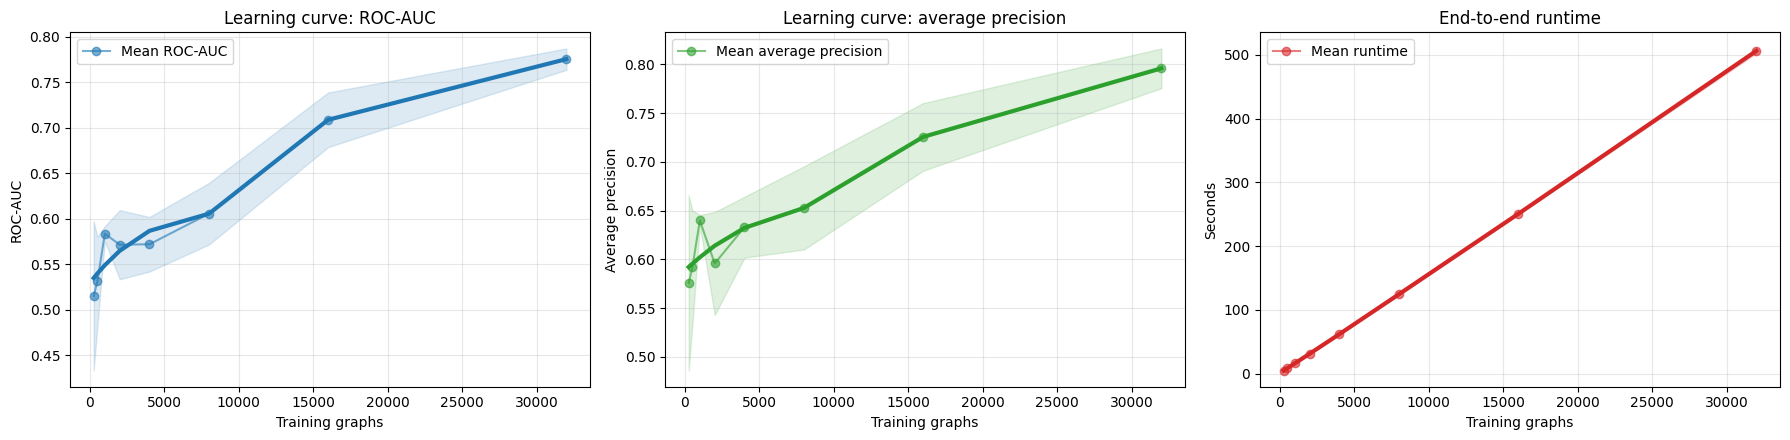

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
frac = 0.8  # Local quadratic LOESS span; adjust between 0 and 1 for more or less smoothing.
x = results_df['train_size'].to_numpy()

plot_series_with_band_loess(
    axes[0],
    x,
    results_df['mean_roc_auc'],
    y_std=results_df['std_roc_auc'],
    frac=frac,
    label='Mean ROC-AUC',
)
axes[0].set_xlabel('Training graphs')
axes[0].set_ylabel('ROC-AUC')
axes[0].set_title('Learning curve: ROC-AUC')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

plot_series_with_band_loess(
    axes[1],
    x,
    results_df['mean_avg_precision'],
    y_std=results_df['std_avg_precision'],
    frac=frac,
    color='tab:green',
    label='Mean average precision',
)
axes[1].set_xlabel('Training graphs')
axes[1].set_ylabel('Average precision')
axes[1].set_title('Learning curve: average precision')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plot_series_with_band_loess(
    axes[2],
    x,
    results_df['mean_runtime_sec'],
    y_std=results_df['std_runtime_sec'],
    frac=frac,
    color='tab:red',
    label='Mean runtime',
)
axes[2].set_xlabel('Training graphs')
axes[2].set_ylabel('Seconds')
axes[2].set_title('End-to-end runtime')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()


## Minimal Full-Stream `partial_fit` Example

For the default HIV setup, `NSPPK.fit(...)` is a no-op because no attribute embedding or clustering must be learned. That means `stream_from(...)` can directly yield supervised `(X_batch, y_batch)` pairs when a `label_extractor` is provided.


In [ ]:
%%time

stream_vectorizer = NSPPK(
    radius=RADIUS,
    distance=DISTANCE,
    connector=CONNECTOR,
    nbits=NBIT,
    dense=False,
    parallel=PARALLEL,
)

stream_model = SGDClassifier(loss='log_loss', alpha=1e-5, penalty='l2', random_state=RANDOM_STATE)
classes = np.array([0, 1])

for batch_idx, (X_batch, y_batch) in enumerate(
    stream_vectorizer.stream_from(
        DATASET_FILE,
        'smiles',
        batch_size=BATCH_SIZE,
        label_extractor=lambda graph: int(graph.graph['HIV_active']),
    )
):
    if batch_idx == 0:
        stream_model.partial_fit(X_batch, y_batch, classes=classes)
    else:
        stream_model.partial_fit(X_batch, y_batch)

stream_model


CPU times: user 60 μs, sys: 29 μs, total: 89 μs
Wall time: 95.6 μs


TypeError: NSPPK.stream_from() got an unexpected keyword argument 'label_extractor'